# RNN from scratch (NumPy) — sequence classification

Classifies binary sequences of length 5 by whether their sum is `> 2` (class 1) or `<= 2` (class 0), using a hand-rolled RNN (forward pass, softmax, cross-entropy loss, and backpropagation through time — all implemented manually with NumPy, no deep learning framework).

## 1. Imports & data generation

In [3]:
import numpy as np

np.random.seed(42)

num_samples = 1000
sequence_length = 5
input_size = 1

X = np.random.randint(0, 2, size=(num_samples, sequence_length, input_size))
y = (np.sum(X, axis=1) > 2).astype(int).reshape(-1)

print(X.shape, y.shape)
print(X[0].ravel(), "-> class", y[0])

(1000, 5, 1) (1000,)
[0 1 0 0 0] -> class 0


In [17]:
y


array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,

## 2. One-hot encode labels

In [4]:
num_classes = 2

y_one_hot = np.zeros((num_samples, num_classes))
y_one_hot[np.arange(num_samples), y] = 1

## 3. Train / test split

In [5]:
split = int(0.8 * num_samples)

X_train = X[:split]
y_train = y_one_hot[:split]

X_test = X[split:]
y_test = y[split:]

## 4. RNN parameters

`input_size=1`, `hidden_size=16`, `output_size=2` — see shapes below.

In [6]:
hidden_size = 16
output_size = 2

Wxh = np.random.randn(input_size, hidden_size) * 0.1   # input -> hidden
Whh = np.random.randn(hidden_size, hidden_size) * 0.1  # hidden -> hidden
bh = np.zeros((1, hidden_size))                        # hidden bias

Why = np.random.randn(hidden_size, output_size) * 0.1  # hidden -> output
by = np.zeros((1, output_size))                        # output bias

for name, w in [("Wxh", Wxh), ("Whh", Whh), ("bh", bh), ("Why", Why), ("by", by)]:
    print(name, w.shape)

Wxh (1, 16)
Whh (16, 16)
bh (1, 16)
Why (16, 2)
by (1, 2)


## 5. Activation functions

In [7]:
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## 6. Forward propagation

Same weights are reused at every timestep; only the final hidden state is passed to the output layer.

In [8]:
def forward(X):
    batch_size = X.shape[0]
    h = np.zeros((batch_size, hidden_size))

    hidden_states = []
    pre_activations = []

    for t in range(sequence_length):
        x_t = X[:, t, :]
        z_t = np.dot(x_t, Wxh) + np.dot(h, Whh) + bh
        h = np.tanh(z_t)

        pre_activations.append(z_t)
        hidden_states.append(h)

    logits = np.dot(h, Why) + by
    probabilities = softmax(logits)

    return probabilities, hidden_states, pre_activations

## 7. Cross-entropy loss

In [9]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
    return loss

## 8. Backpropagation through time (BPTT)

The gradient flows backward from the loss through every timestep, shrinking at each hop via `tanh_derivative` and `Whh` (classic vanishing-gradient behavior).

In [10]:
def backward(X, y_true, probabilities, hidden_states, pre_activations):
    batch_size = X.shape[0]

    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dbh = np.zeros_like(bh)
    dWhy = np.zeros_like(Why)
    dby = np.zeros_like(by)

    d_logits = (probabilities - y_true) / batch_size

    h_last = hidden_states[-1]
    dWhy = np.dot(h_last.T, d_logits)
    dby = np.sum(d_logits, axis=0, keepdims=True)

    dh = np.dot(d_logits, Why.T)

    for t in reversed(range(sequence_length)):
        h_t = hidden_states[t]
        h_previous = np.zeros_like(h_t) if t == 0 else hidden_states[t - 1]
        x_t = X[:, t, :]

        dz = dh * tanh_derivative(pre_activations[t])

        dWxh += np.dot(x_t.T, dz)
        dWhh += np.dot(h_previous.T, dz)
        dbh += np.sum(dz, axis=0, keepdims=True)

        dh = np.dot(dz, Whh.T)

    return dWxh, dWhh, dbh, dWhy, dby

## 9. Training loop

Mini-batch SGD with gradient clipping.

In [11]:
learning_rate = 0.01
epochs = 1000
batch_size = 32

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]

    total_loss = 0

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train[start:end]
        y_batch = y_train[start:end]

        probabilities, hidden_states, pre_activations = forward(X_batch)
        loss = cross_entropy_loss(y_batch, probabilities)
        total_loss += loss

        dWxh, dWhh, dbh, dWhy, dby = backward(
            X_batch, y_batch, probabilities, hidden_states, pre_activations
        )

        dWxh = np.clip(dWxh, -5, 5)
        dWhh = np.clip(dWhh, -5, 5)
        dbh = np.clip(dbh, -5, 5)
        dWhy = np.clip(dWhy, -5, 5)
        dby = np.clip(dby, -5, 5)

        Wxh -= learning_rate * dWxh
        Whh -= learning_rate * dWhh
        bh -= learning_rate * dbh
        Why -= learning_rate * dWhy
        by -= learning_rate * dby

    if epoch % 100 == 0:
        predictions = np.argmax(probabilities, axis=1)
        accuracy = np.mean(predictions == np.argmax(y_batch, axis=1))
        print(f"Epoch {epoch:4d} | Loss: {total_loss:.4f} | Accuracy: {accuracy:.4f}")

Epoch    0 | Loss: 17.4021 | Accuracy: 0.4688
Epoch  100 | Loss: 0.8026 | Accuracy: 1.0000
Epoch  200 | Loss: 0.2427 | Accuracy: 1.0000
Epoch  300 | Loss: 0.1341 | Accuracy: 1.0000
Epoch  400 | Loss: 0.0891 | Accuracy: 1.0000
Epoch  500 | Loss: 0.0650 | Accuracy: 1.0000
Epoch  600 | Loss: 0.0502 | Accuracy: 1.0000
Epoch  700 | Loss: 0.0405 | Accuracy: 1.0000
Epoch  800 | Loss: 0.0337 | Accuracy: 1.0000
Epoch  900 | Loss: 0.0287 | Accuracy: 1.0000


## 10. Prediction helper

In [12]:
def predict(X):
    probabilities, _, _ = forward(X)
    predictions = np.argmax(probabilities, axis=1)
    return predictions, probabilities

## 11. Test set evaluation

In [13]:
predictions, probabilities = predict(X_test)
accuracy = np.mean(predictions == y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 1.0


## **archi**

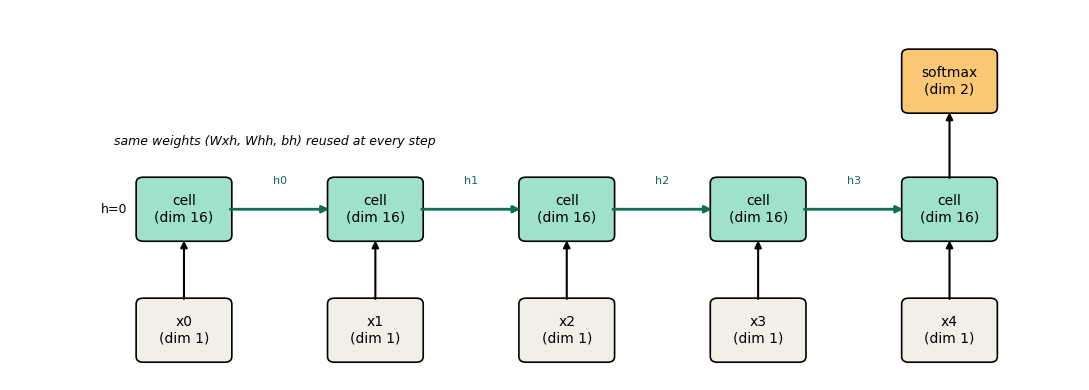

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_rnn_architecture(seq_len=5, in_size=1, hid_size=16, out_size=2):
    fig, ax = plt.subplots(figsize=(2.2 * seq_len, 4))

    box_w, box_h = 1.0, 0.8
    x_gap = 2.2
    y_input, y_cell, y_output = 0.5, 2.2, 4.0

    def box(x, y, label, color):
        rect = patches.FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.2, edgecolor="black", facecolor=color
        )
        ax.add_patch(rect)
        ax.text(x, y, label, ha="center", va="center", fontsize=10)

    def arrow(x0, y0, x1, y1, color="black", lw=1.5):
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=lw)
        )

    # initial hidden state
    x0 = 0.5
    ax.text(x0 - 0.8, y_cell, "h=0", ha="center", va="center", fontsize=9)
    arrow(x0 - 0.55, y_cell, x0 - box_w / 2 - 0.05, y_cell)

    prev_x = None
    for t in range(seq_len):
        x = x0 + t * x_gap

        box(x, y_input, f"x{t}\n(dim {in_size})", "#F1EFE8")
        box(x, y_cell, f"cell\n(dim {hid_size})", "#9FE1CB")
        arrow(x, y_input + box_h / 2, x, y_cell - box_h / 2)

        if prev_x is not None:
            arrow(prev_x + box_w / 2, y_cell, x - box_w / 2, y_cell, color="#0F6E56", lw=2)
            ax.text((prev_x + x) / 2, y_cell + 0.35, f"h{t-1}", ha="center", fontsize=8, color="#0F6E56")

        prev_x = x

    # output layer, fed only by final hidden state
    box(prev_x, y_output, f"softmax\n(dim {out_size})", "#FAC775")
    arrow(prev_x, y_cell + box_h / 2, prev_x, y_output - box_h / 2)

    ax.text(x0 - 0.8, y_cell + 0.9, "same weights (Wxh, Whh, bh) reused at every step",
            fontsize=9, style="italic")

    ax.set_xlim(-1.5, prev_x + 1.5)
    ax.set_ylim(-0.2, y_output + 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

draw_rnn_architecture(seq_len=5, in_size=1, hid_size=16, out_size=2)

## 12. Try some new sequences

In [14]:
test_sequences = np.array([
    [[0], [0], [0], [1], [0]],   # sum = 1 -> class 0
    [[1], [1], [0], [1], [0]],   # sum = 3 -> class 1
    [[1], [1], [1], [0], [0]],   # sum = 3 -> class 1
    [[0], [1], [0], [0], [0]]    # sum = 1 -> class 0
])

predictions, probabilities = predict(test_sequences)

print("Predictions:")
print(predictions)

print("\nProbabilities:")
print(probabilities)

Predictions:
[0 1 1 0]

Probabilities:
[[9.99999487e-01 5.13047073e-07]
 [2.34211693e-04 9.99765788e-01]
 [3.82648585e-03 9.96173514e-01]
 [9.99999864e-01 1.35936793e-07]]
